In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
data = pd.read_csv('data/gena_and_moderngena.csv')
data.head()

,feature_class,model_name,pct_1,pct_0,baseline_pct_1_mean,baseline_pct_1_std,observed_baseline_ratio,predictions_sum,total_bp
0,Alu,gena-lm,0.249355,0.750645,0.100547,0.001602,2.479976,52079.0,208855
1,CR1,gena-lm,0.048506,0.951494,0.100059,0.002061,0.484770,4418.0,91082
2,ERV1,gena-lm,0.132683,0.867317,0.100294,0.000942,1.322937,127948.0,964314
3,ERVK,gena-lm,0.078277,0.921723,0.101900,0.007851,0.768173,1788.0,22842
4,ERVL,gena-lm,0.072598,0.927402,0.100654,0.001177,0.721268,52584.0,724315


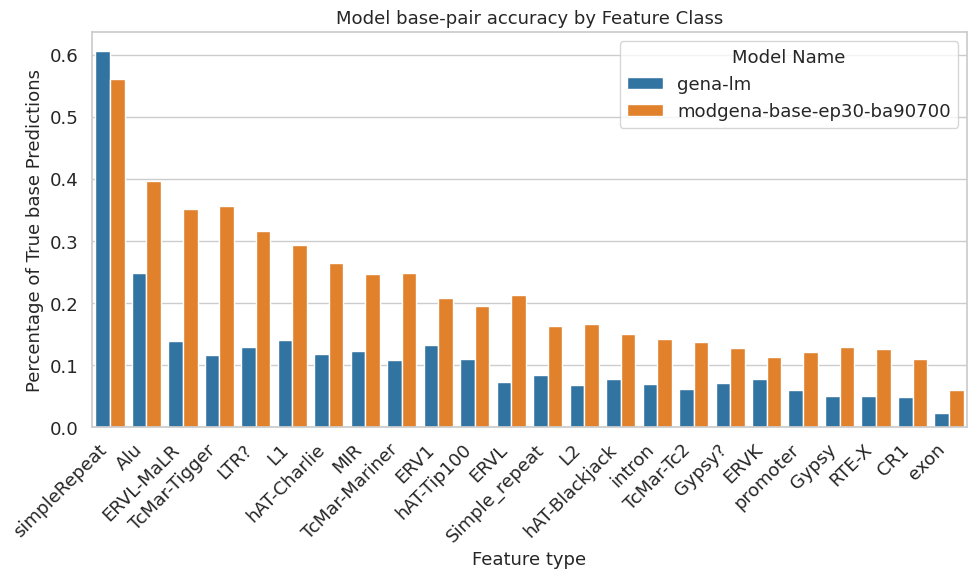

In [6]:
# Compute the mean pct_1 per feature_class (across all models)
mean_pct1 = data.groupby("feature_class")["pct_1"].mean()
# Create an ordering of feature_class by descending mean pct_1
ordered_feature_classes = mean_pct1.sort_values(ascending=False).index.tolist()

plt.figure(figsize=(10, 6))
sns.set_context("notebook", font_scale=1.13)  # font_scale ~13pt for default context
sns.set_style("whitegrid")
ax = sns.barplot(
    data=data,
    x="feature_class",
    y="pct_1",
    hue="model_name",
    order=ordered_feature_classes
)
ax.set_xlabel("Feature type", fontsize=13)
ax.set_ylabel("Percentage of True base Predictions", fontsize=13)
ax.set_title("Model base-pair accuracy by Feature Class", fontsize=13)
ax.tick_params(axis='both', labelsize=13)
ax.legend(title="Model Name", fontsize=13, title_fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


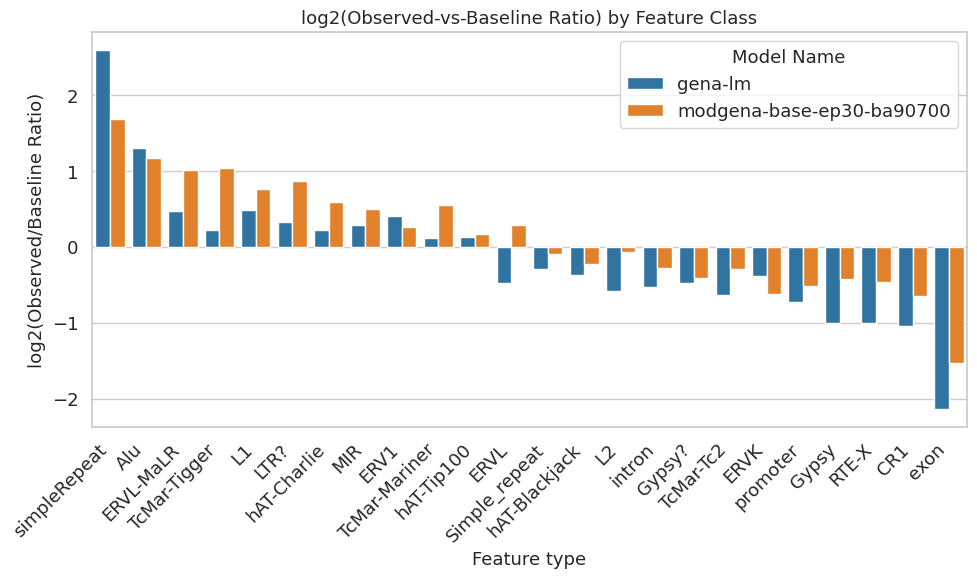

In [8]:
# Log2-transform the observed_baseline_ratio
data["log2_obs_baseline_ratio"] = np.log2(data["observed_baseline_ratio"])

# Compute the mean of the log2 observed_baseline_ratio per feature_class (across all models)
mean_log2_obs_baseline_ratio = data.groupby("feature_class")["log2_obs_baseline_ratio"].mean()
# Create an ordering of feature_class by descending mean log2 observed_baseline_ratio
ordered_feature_classes_log2_obs_baseline = mean_log2_obs_baseline_ratio.sort_values(ascending=False).index.tolist()

plt.figure(figsize=(10, 6))
sns.set_context("notebook", font_scale=1.13)
sns.set_style("whitegrid")
ax = sns.barplot(
    data=data,
    x="feature_class",
    y="log2_obs_baseline_ratio",
    hue="model_name",
    order=ordered_feature_classes_log2_obs_baseline
)
ax.set_xlabel("Feature type", fontsize=13)
ax.set_ylabel("log2(Observed/Baseline Ratio)", fontsize=13)
ax.set_title("log2(Observed-vs-Baseline Ratio) by Feature Class", fontsize=13)
ax.tick_params(axis='both', labelsize=13)
ax.legend(title="Model Name", fontsize=13, title_fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
